In [49]:
# Cell 1: imports & plotting setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns





In [ ]:
# Cell 2: load CSVs
mls_path = r"C:\Users\nickj\Downloads\mls.csv"
pop_path = r"C:\Users\nickj\Downloads\mls_city_population_estimates.csv"  # file created earlier

mls = pd.read_csv(mls_path)
pop = pd.read_csv(pop_path)

# display data
print("MLS rows:", len(mls))
display(mls.head())
print("Population rows:", len(pop))
display(pop.head())


MLS rows: 30


,team,city,state,latitude,longitude,stadium,stadium_capacity,joined,head_coach,url,wikipedia_url,logo_url
0,Atlanta United FC,Atlanta,Georgia,33.755556,-84.400000,Mercedes-Benz Stadium,42500,2017,Ronny Deila,https://www.atlutd.com/,https://en.wikipedia.org/wiki/Atlanta_United_FC,https://upload.wikimedia.org/wikipedia/en/thum...
1,Austin FC,Austin,Texas,30.387700,-97.719500,Q2 Stadium,20738,2021,Nico Estévez,https://www.austinfc.com/,https://en.wikipedia.org/wiki/Austin_FC,https://upload.wikimedia.org/wikipedia/en/thum...
2,CF Montréal,Montreal,Quebec,45.563056,-73.552500,Saputo Stadium,19619,2012,Laurent Courtois,https://www.cfmontreal.com/,https://en.wikipedia.org/wiki/CF_Montr%C3%A9al,https://upload.wikimedia.org/wikipedia/en/thum...
3,Charlotte FC,Charlotte,North Carolina,35.225833,-80.852778,Bank of America Stadium,38000,2022,Dean Smith,https://www.charlottefootballclub.com/,https://en.wikipedia.org/wiki/Charlotte_FC,https://upload.wikimedia.org/wikipedia/en/thum...
4,Chicago Fire FC,Chicago,Illinois,41.862300,-87.616700,Soldier Field,24995,1998,Gregg Berhalter,https://www.chicagofirefc.com/,https://en.wikipedia.org/wiki/Chicago_Fire_FC,https://upload.wikimedia.org/wikipedia/commons...


Population rows: 30


,city,state,population
0,Atlanta,Georgia,499896
1,Austin,Texas,964254
2,Montreal,Quebec,1762949
3,Charlotte,North Carolina,874579
4,Chicago,Illinois,2746388


In [ ]:
# merge and basic cleaning
mls['city'] = mls['city'].astype(str).str.strip()
pop['city'] = pop['city'].astype(str).str.strip()

df = mls.merge(pop[['city','population']], on='city', how='left')

# check for any missing population values
missing = df[df['population'].isna()][['team','city','state']]
print("Missing population rows (if any):")
display(missing)


Missing population rows (if any):


,team,city,state


In [ ]:
# compute stadium capacity per 100k people
df['capacity_per_100k'] = df['stadium_capacity'] / (df['population'] / 100_000)

# add era column for simple comparisons
df['era'] = np.where(df['joined'] >= 2010, 'recent', 'early')

# save merged file 
out_merged = r"C:\Users\nickj\Downloads\mls_with_pop.csv"
df.to_csv(out_merged, index=False)
print("Merged file saved to:", out_merged)


Merged file saved to: C:\Users\nickj\Downloads\mls_with_pop.csv


In [53]:
# show top / bottom teams by capacity_per_100k
top10 = df.sort_values('capacity_per_100k', ascending=False).head(10)[
    ['team','city','stadium','stadium_capacity','population','capacity_per_100k']
]
bottom10 = df.sort_values('capacity_per_100k', ascending=True).head(10)[
    ['team','city','stadium','stadium_capacity','population','capacity_per_100k']
]

print("Top 10 (seats per 100k):")
display(top10.style.format({"capacity_per_100k":"{:.1f}"}))
print("\nBottom 10 (seats per 100k):")
display(bottom10.style.format({"capacity_per_100k":"{:.1f}"}))



Top 10 (seats per 100k):


,team,city,stadium,stadium_capacity,population,capacity_per_100k
18,New York Red Bulls,Harrison,Sports Illustrated Stadium,25000,14583,171432.5
16,New England Revolution,Foxborough,Gillette Stadium,20000,18618,107422.9
20,Philadelphia Union,Chester,Subaru Park,18500,33972,54456.6
5,Colorado Rapids,Commerce City,Dick's Sporting Goods Park,18061,62418,28935.6
12,LA Galaxy,Carson,Dignity Health Sports Park,27000,95558,28255.1
22,Real Salt Lake,Sandy,America First Field,20213,96904,20858.8
26,Sporting Kansas City,Kansas City,Children's Mercy Park,18467,156607,11791.9
11,Inter Miami CF,Fort Lauderdale,Chase Stadium,21550,182760,11791.4
9,FC Dallas,Frisco,Toyota Stadium,19096,200490,9524.7
0,Atlanta United FC,Atlanta,Mercedes-Benz Stadium,42500,499896,8501.8



Bottom 10 (seats per 100k):


,team,city,stadium,stadium_capacity,population,capacity_per_100k
13,Los Angeles FC,Los Angeles,BMO Stadium,22000,3898747,564.3
4,Chicago Fire FC,Chicago,Soldier Field,24995,2746388,910.1
10,Houston Dynamo FC,Houston,Shell Energy Stadium,22039,2304580,956.3
28,Toronto FC,Toronto,BMO Field,28351,2794356,1014.6
2,CF Montréal,Montreal,Saputo Stadium,19619,1762949,1112.9
24,San Jose Earthquakes,San Jose,PayPal Park,18000,1021795,1761.6
17,New York City FC,The Bronx,Yankee Stadium,30321,1472654,2058.9
1,Austin FC,Austin,Q2 Stadium,20738,964254,2150.7
6,Columbus Crew,Columbus,Lower.com Field,20371,898553,2267.1
23,San Diego FC,San Diego,Snapdragon Stadium,35000,1386932,2523.6


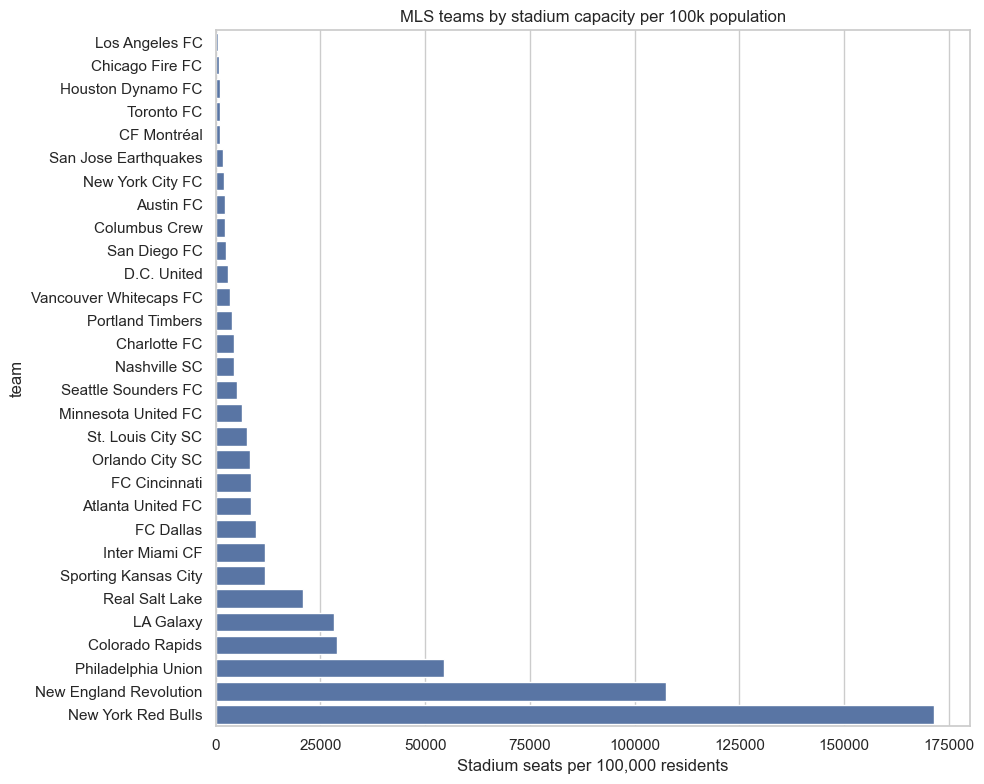

In [ ]:
# bar chart of teams by capacity_per_100k
top30 = df.sort_values('capacity_per_100k', ascending=False).head(30).set_index('team').sort_values('capacity_per_100k')
plt.figure(figsize=(10,8))
sns.barplot(x='capacity_per_100k', y=top30.index, data=top30, orient='h')
plt.xlabel('Stadium seats per 100,000 residents')
plt.title('MLS teams by stadium capacity per 100k population')
plt.tight_layout()
plt.savefig(r"C:\Users\nickj\Downloads\top15_capacity_per_100k.png", dpi=200, bbox_inches='tight')
plt.show()
